#  DBSCAN, Clustering Jerárquico y Evaluación de Modelos

En la clase anterior vimos K-Means: rápido y fácil de interpretar, pero con
dos limitaciones importantes:

1. Asume que los clusters tienen **forma esférica/convexa**.
2. Hay que decidir **`k` de antemano**.

Hoy vemos dos algoritmos que no comparten esas limitaciones (DBSCAN y
Clustering Jerárquico), cómo **medir objetivamente** qué tan buenos son los
clusters obtenidos, cómo **clasificar un dato nuevo** con un modelo ya
entrenado, y cómo **guardar el modelo en disco** para reutilizarlo sin
reentrenar.

Contenido de hoy:
1. DBSCAN: clustering basado en densidad
2. Clustering Jerárquico Aglomerativo y dendrogramas
3. Métricas internas de validación (Silhouette, Davies-Bouldin, Calinski-Harabasz)
4. Asignar un dato nuevo a un cluster ya entrenado
5. Persistencia del modelo con `joblib`

In [1]:
%pip install numpy pandas matplotlib scikit-learn scipy joblib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.cluster        import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing  import StandardScaler
from sklearn.neighbors      import NearestNeighbors, KNeighborsClassifier
from sklearn.datasets       import make_moons
from sklearn.metrics        import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram

plt.style.use("seaborn-v0_8-whitegrid")
SEED = 42
rng  = np.random.default_rng(seed=SEED)

---
## 1. DBSCAN: clustering basado en densidad

DBSCAN no asume que los grupos sean esféricos: en su lugar, define un
cluster como una región **densa** de puntos, separada de otras regiones
densas por zonas de baja densidad. No recibe `k`; en su lugar recibe dos
parámetros:

- **`eps`**: radio de vecindad alrededor de cada punto.
- **`min_samples`**: cantidad mínima de vecinos dentro de ese radio para
  considerar un punto como parte densa de un cluster.

Los puntos que no tienen suficientes vecinos cercanos quedan marcados como
**ruido** (etiqueta `-1`) — no se fuerzan a pertenecer a ningún grupo.

Primero generamos un dataset sintético con dos formas curvas entrelazadas,
donde K-Means falla de forma muy visible.

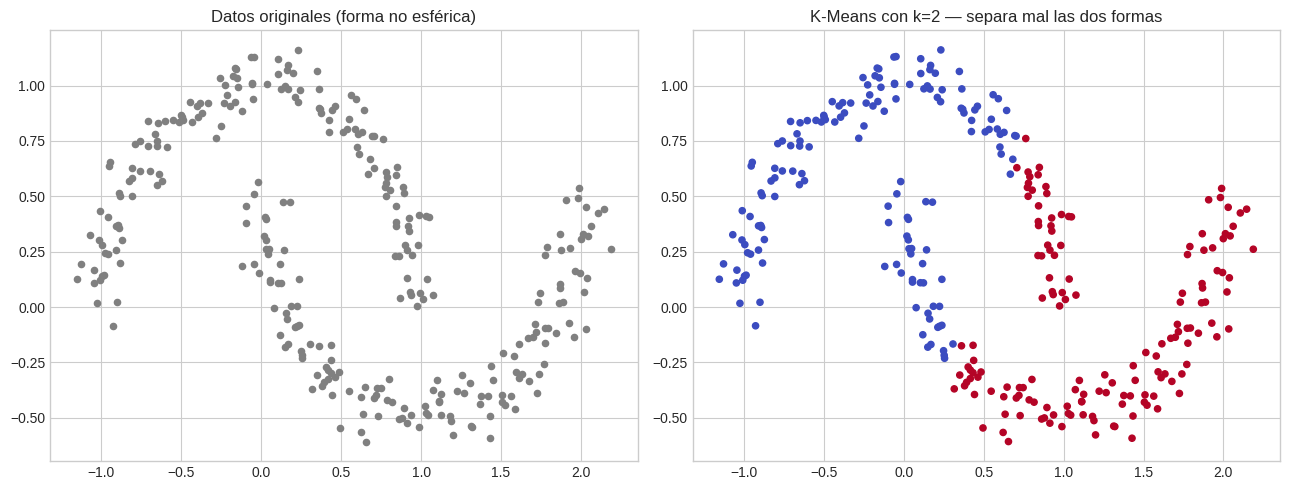

In [3]:
X_lunas, _ = make_moons(n_samples=300, noise=0.07, random_state=SEED)

modelo_kmeans_lunas = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit(X_lunas)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X_lunas[:, 0], X_lunas[:, 1], s=20, color="gray")
axes[0].set_title("Datos originales (forma no esférica)")

axes[1].scatter(X_lunas[:, 0], X_lunas[:, 1], c=modelo_kmeans_lunas.labels_, cmap="coolwarm", s=20)
axes[1].set_title("K-Means con k=2 — separa mal las dos formas")
plt.tight_layout()
plt.show()

# K-Means corta el espacio con fronteras rectas alrededor de centroides, así
# que no puede seguir la forma curva de cada grupo: parte cada "luna" por la
# mitad en vez de mantenerla completa.

### 1.1 Eligiendo `eps` con la gráfica de distancia al k-ésimo vecino

Una forma común de elegir `eps` es calcular, para cada punto, la distancia
a su `min_samples`-ésimo vecino más cercano, ordenar esas distancias de
menor a mayor y graficarlas. El punto donde la curva sube bruscamente es
un buen candidato para `eps` — antes de ese punto los puntos están en zonas
densas; después, en zonas dispersas.

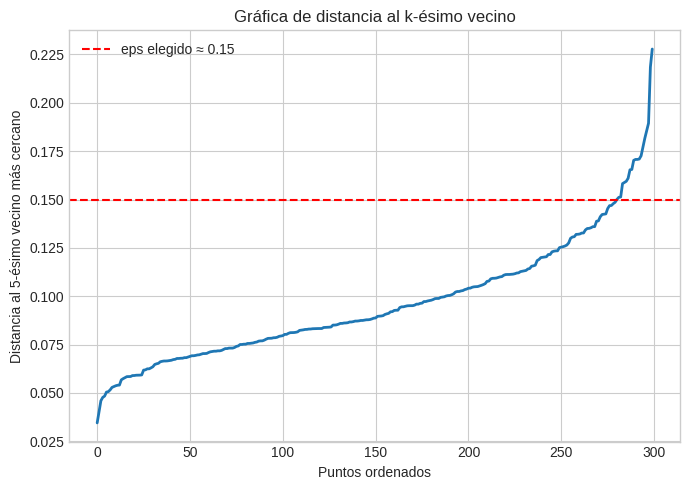

In [4]:
MIN_SAMPLES = 5
vecinos = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_lunas)
distancias, _ = vecinos.kneighbors(X_lunas)
k_distancias  = np.sort(distancias[:, -1])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(k_distancias, linewidth=2)
ax.axhline(y=0.15, color="red", linestyle="--", label="eps elegido ≈ 0.15")
ax.set_xlabel("Puntos ordenados")
ax.set_ylabel(f"Distancia al {MIN_SAMPLES}-ésimo vecino más cercano")
ax.set_title("Gráfica de distancia al k-ésimo vecino")
ax.legend()
plt.tight_layout()
plt.show()

Clusters encontrados: 2
Puntos de ruido      : 2


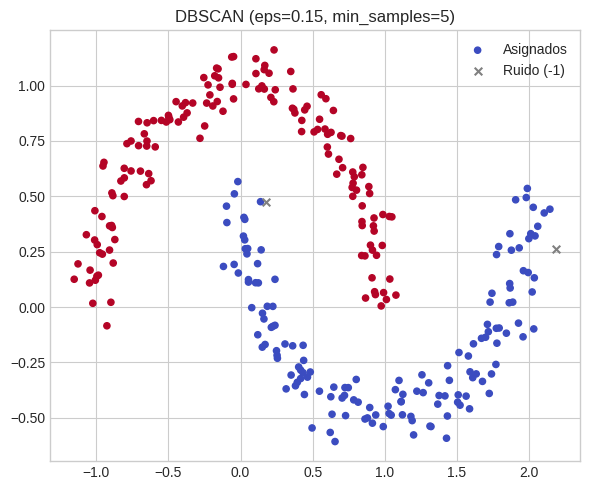

In [5]:
EPS = 0.15
modelo_dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(X_lunas)

n_clusters_dbscan = len(set(modelo_dbscan.labels_)) - (1 if -1 in modelo_dbscan.labels_ else 0)
n_ruido           = (modelo_dbscan.labels_ == -1).sum()
print(f"Clusters encontrados: {n_clusters_dbscan}")
print(f"Puntos de ruido      : {n_ruido}")

fig, ax = plt.subplots(figsize=(6, 5))
es_ruido = modelo_dbscan.labels_ == -1
ax.scatter(X_lunas[~es_ruido, 0], X_lunas[~es_ruido, 1],
           c=modelo_dbscan.labels_[~es_ruido], cmap="coolwarm", s=20, label="Asignados")
ax.scatter(X_lunas[es_ruido, 0], X_lunas[es_ruido, 1],
           c="gray", marker="x", s=30, label="Ruido (-1)")
ax.set_title(f"DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES})")
ax.legend()
plt.tight_layout()
plt.show()

# A diferencia de K-Means, DBSCAN sí logra separar correctamente las dos
# formas curvas, y además identifica los puntos que no encajan claramente
# en ninguna de las dos como ruido en vez de forzarlos a un grupo.

---
## 2. Clustering Jerárquico Aglomerativo

Este algoritmo no recibe `k` al inicio. Empieza tratando cada punto como su
propio cluster, y en cada paso **une los dos clusters más cercanos**, hasta
que todo queda en un solo cluster. El resultado completo se puede dibujar
como un **dendrograma** (árbol), y luego se decide en qué altura "cortar"
el árbol para obtener un número de clusters específico.

Lo aplicamos sobre un dataset pequeño a propósito (15 alimentos descritos
por su composición nutricional), para que el dendrograma sea legible.

In [6]:
alimentos = [
    "Manzana", "Banano", "Naranja", "Fresa", "Sandía",
    "Pechuga de pollo", "Carne de res", "Salmón", "Huevo", "Atún",
    "Arroz blanco", "Pan integral", "Avena", "Pasta", "Quinoa",
]
# Columnas: calorías (kcal/100g), proteína (g), grasa (g), carbohidratos (g).
nutrientes = np.array([
    [52,  0.3,  0.2, 14.0], [89,  1.1,  0.3, 23.0], [47,  0.9,  0.1, 12.0],
    [32,  0.7,  0.3,  8.0], [30,  0.6,  0.2,  8.0],
    [165, 31.0, 3.6,  0.0], [250, 26.0, 17.0, 0.0], [208, 20.0, 13.0, 0.0],
    [155, 13.0, 11.0, 1.1], [132, 28.0, 1.0,  0.0],
    [130, 2.7,  0.3, 28.0], [247, 13.0, 3.4, 41.0], [389, 17.0, 7.0, 66.0],
    [131, 5.0,  1.1, 25.0], [120, 4.4,  1.9, 21.0],
])

df_alimentos = pd.DataFrame(nutrientes, columns=["calorias", "proteina_g", "grasa_g", "carbohidratos_g"],
                             index=alimentos)
scaler_alimentos    = StandardScaler()
nutrientes_escalados = scaler_alimentos.fit_transform(nutrientes)

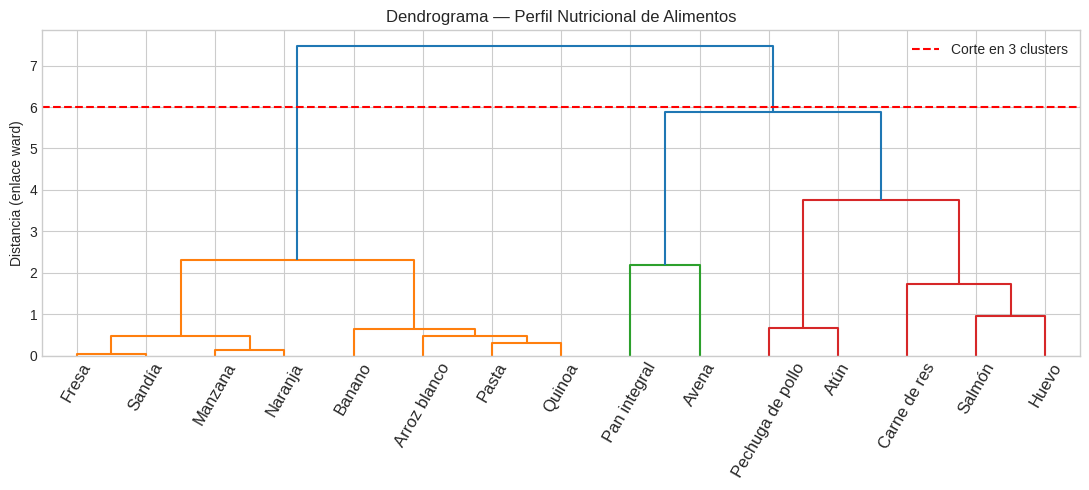

In [7]:
# El dendrograma se construye con scipy a partir de la matriz de enlaces ("linkage").
matriz_enlaces = linkage(nutrientes_escalados, method="ward")

fig, ax = plt.subplots(figsize=(11, 5))
dendrogram(matriz_enlaces, labels=alimentos, leaf_rotation=60, ax=ax)
ax.axhline(y=6, color="red", linestyle="--", label="Corte en 3 clusters")
ax.set_title("Dendrograma — Perfil Nutricional de Alimentos")
ax.set_ylabel("Distancia (enlace ward)")
ax.legend()
plt.tight_layout()
plt.show()

# La altura de cada unión representa qué tan distintos eran los dos grupos
# que se fusionaron. Cortar más abajo (cerca de las hojas) da más clusters
# y más pequeños; cortar más arriba da menos clusters y más generales.

In [8]:
modelo_jerarquico = AgglomerativeClustering(n_clusters=3, linkage="ward")
df_alimentos["segmento"] = modelo_jerarquico.fit_predict(nutrientes_escalados)
df_alimentos.sort_values("segmento")

# El corte en 3 separa, de forma consistente con el dendrograma, frutas
# (bajas calorías y grasa), proteínas animales (alta proteína, bajo
# carbohidrato) y cereales/granos (altos carbohidratos). `linkage="ward"`
# minimiza la varianza dentro de cada cluster al fusionar; otras opciones
# como `"complete"`, `"average"` o `"single"` cambian el criterio de cercanía
# entre clusters y pueden dar resultados distintos.

,calorias,proteina_g,grasa_g,carbohidratos_g,segmento
Carne de res,250.0,26.0,17.0,0.0,0
Salmón,208.0,20.0,13.0,0.0,0
Pechuga de pollo,165.0,31.0,3.6,0.0,0
Huevo,155.0,13.0,11.0,1.1,0
Atún,132.0,28.0,1.0,0.0,0
Naranja,47.0,0.9,0.1,12.0,1
Fresa,32.0,0.7,0.3,8.0,1
Manzana,52.0,0.3,0.2,14.0,1
Sandía,30.0,0.6,0.2,8.0,1
Banano,89.0,1.1,0.3,23.0,1


---
## 3. Métricas internas de validación

A diferencia de un modelo supervisado, aquí no existe una respuesta
correcta contra la cual comparar. Las **métricas internas** evalúan la
calidad del agrupamiento usando solo la estructura de los datos:

| Métrica | Qué mide | Mejor valor |
|---|---|---|
| Silhouette Score | Qué tan parecido es un punto a su propio cluster frente a los demás | Más alto (máx. 1) |
| Davies-Bouldin Index | Qué tan separados y compactos están los clusters entre sí | Más bajo (mín. 0) |
| Calinski-Harabasz Index | Razón entre dispersión entre clusters y dispersión dentro de clusters | Más alto |

Las tres se calculan solo con `X` y las etiquetas de cluster — ninguna
necesita una variable objetivo.

Generamos un nuevo dataset multivariable (consumo energético de edificios)
para aplicarlas, igual que se haría con cualquier resultado de clustering.

In [9]:
N = 280
perfiles_edificio = {
    "moderno_eficiente":  dict(consumo=80,  antiguedad=5,  aislamiento=8.5, pisos=6,  ocupacion=70),
    "antiguo_ineficiente":dict(consumo=220, antiguedad=45, aislamiento=3.0, pisos=3,  ocupacion=55),
    "renovado":           dict(consumo=130, antiguedad=35, aislamiento=7.0, pisos=4,  ocupacion=60),
}
tipos = rng.choice(list(perfiles_edificio.keys()), size=N, p=[0.35, 0.35, 0.30])

filas = []
for tipo in tipos:
    p = perfiles_edificio[tipo]
    filas.append({
        "consumo_kwh_m2"        : max(10, rng.normal(p["consumo"], 18)),
        "antiguedad_anios"      : max(0,  rng.normal(p["antiguedad"], 6)),
        "aislamiento_score"     : np.clip(rng.normal(p["aislamiento"], 0.8), 0, 10),
        "num_pisos"             : max(1,  round(rng.normal(p["pisos"], 1.5))),
        "ocupacion_promedio_pct": np.clip(rng.normal(p["ocupacion"], 8), 0, 100),
    })

df_edificios   = pd.DataFrame(filas)
cols_edificios = df_edificios.columns.tolist()

scaler_edificios = StandardScaler()
X_edificios      = scaler_edificios.fit_transform(df_edificios[cols_edificios])
print(f"Dataset de edificios: {df_edificios.shape}")

Dataset de edificios: (280, 5)


In [10]:
# Calculamos las tres métricas para varios valores de k.
resultados = []
for k in range(2, 8):
    modelo_k   = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_edificios)
    etiquetas_k = modelo_k.labels_
    resultados.append({
        "k"                : k,
        "silhouette"       : silhouette_score(X_edificios, etiquetas_k),
        "davies_bouldin"   : davies_bouldin_score(X_edificios, etiquetas_k),
        "calinski_harabasz": calinski_harabasz_score(X_edificios, etiquetas_k),
    })

df_metricas = pd.DataFrame(resultados)
df_metricas

,k,silhouette,davies_bouldin,calinski_harabasz
0,2,0.469614,0.793241,383.120654
1,3,0.424782,0.948578,365.462676
2,4,0.372312,1.175493,280.841531
3,5,0.309136,1.344562,242.225459
4,6,0.254189,1.404448,226.126645
5,7,0.251406,1.329070,209.811184


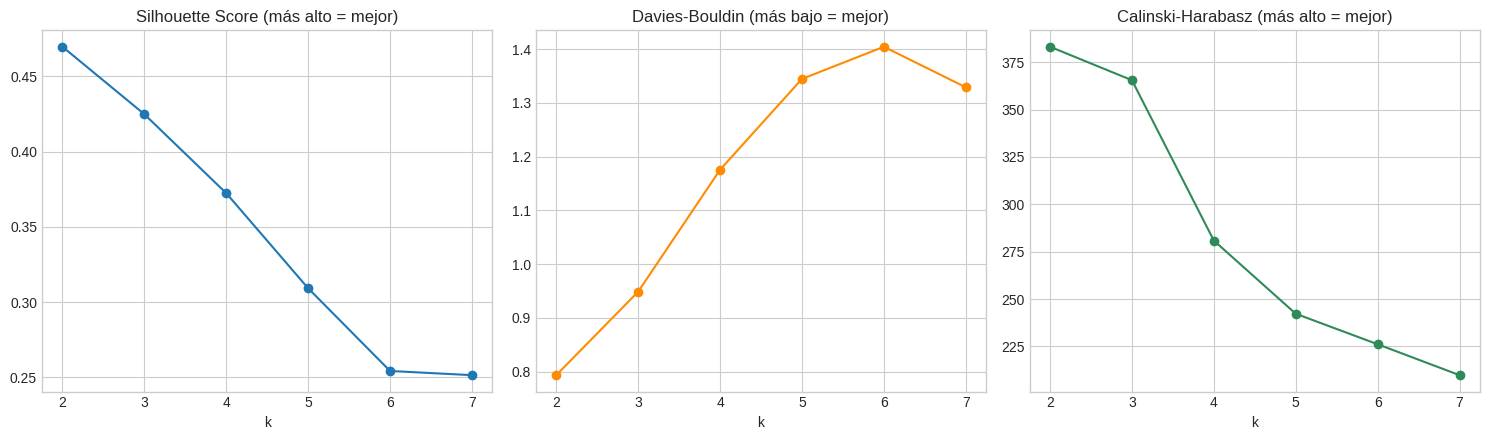

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(df_metricas["k"], df_metricas["silhouette"], marker="o")
axes[0].set_title("Silhouette Score (más alto = mejor)")
axes[1].plot(df_metricas["k"], df_metricas["davies_bouldin"], marker="o", color="darkorange")
axes[1].set_title("Davies-Bouldin (más bajo = mejor)")
axes[2].plot(df_metricas["k"], df_metricas["calinski_harabasz"], marker="o", color="seagreen")
axes[2].set_title("Calinski-Harabasz (más alto = mejor)")
for ax in axes:
    ax.set_xlabel("k")
plt.tight_layout()
plt.show()

# Las tres métricas coinciden en señalar k=3 como una buena elección, lo cual
# es consistente porque el dataset se generó con tres perfiles reales de
# edificio. En la práctica rara vez las tres coinciden tan claramente — ante
# un desacuerdo, el criterio de negocio para interpretar los grupos pesa
# tanto como el número que indique cada métrica.

In [12]:
K_FINAL = 3
scaler_final = scaler_edificios
modelo_final = KMeans(n_clusters=K_FINAL, n_init=10, random_state=SEED).fit(X_edificios)
df_edificios["segmento"] = modelo_final.labels_

print(f"Métricas finales con k={K_FINAL}:")
print(f"  Silhouette        : {silhouette_score(X_edificios, modelo_final.labels_):.3f}")
print(f"  Davies-Bouldin    : {davies_bouldin_score(X_edificios, modelo_final.labels_):.3f}")
print(f"  Calinski-Harabasz : {calinski_harabasz_score(X_edificios, modelo_final.labels_):.1f}")
df_edificios.groupby("segmento")[cols_edificios].mean().round(1)

Métricas finales con k=3:
  Silhouette        : 0.425
  Davies-Bouldin    : 0.949
  Calinski-Harabasz : 365.5


,consumo_kwh_m2,antiguedad_anios,aislamiento_score,num_pisos,ocupacion_promedio_pct
segmento,,,,,
0,80.7,6.1,8.4,6.1,70.5
1,219.9,45.5,2.9,2.9,53.7
2,132.0,34.8,7.0,3.8,60.2


---
## 4. Asignar un dato nuevo a un cluster ya entrenado

Hasta ahora todos los clusters se calcularon sobre el dataset completo de
una sola vez. En la práctica, después de entrenar, suele llegar un dato
nuevo que no participó del entrenamiento y que se necesita ubicar dentro
de uno de los clusters ya encontrados, sin repetir todo el proceso.

Esto se resuelve distinto según el algoritmo:

- **K-Means**: tiene centroides explícitos, así que `.predict()` simplemente
  calcula la distancia del punto nuevo a cada centroide y devuelve el más
  cercano. Es una operación nativa e inmediata.
- **DBSCAN y Jerárquico**: no guardan centroides ni una regla de decisión
  reutilizable — solo producen una etiqueta para los puntos que ya vieron.
  Para aproximar una asignación de un punto nuevo, una estrategia simple y
  razonable es buscar su o sus vecinos más cercanos **entre los puntos ya
  etiquetados** y copiar la etiqueta mayoritaria — esto es, en esencia,
  aplicar **KNN (K-Nearest Neighbors)** sobre los datos ya agrupados.

In [13]:
# Caso 1: K-Means → predict() nativo.
edificio_nuevo = pd.DataFrame([{
    "consumo_kwh_m2": 95, "antiguedad_anios": 8, "aislamiento_score": 8.0,
    "num_pisos": 5, "ocupacion_promedio_pct": 65,
}])
edificio_nuevo_scaled = scaler_final.transform(edificio_nuevo[cols_edificios])
segmento_predicho     = modelo_final.predict(edificio_nuevo_scaled)[0]
print(f"K-Means → el edificio nuevo se asigna al segmento {segmento_predicho} (predict nativo)")

K-Means → el edificio nuevo se asigna al segmento 0 (predict nativo)


DBSCAN (aproximado con KNN) → el punto nuevo se asigna al cluster 1


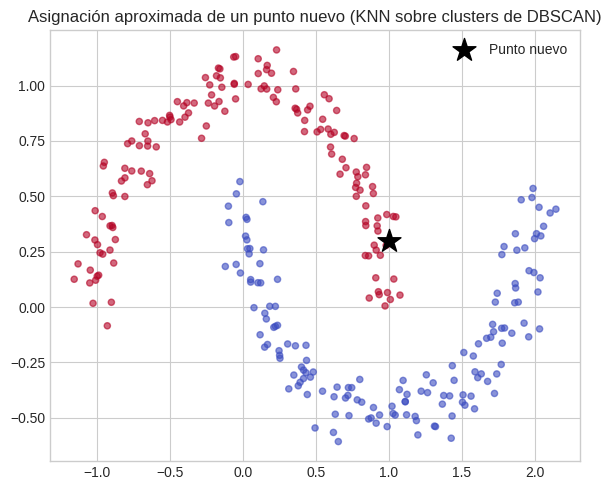

In [14]:
# Caso 2: DBSCAN → sin predict nativo, se aproxima con KNN sobre los puntos ya etiquetados.
# Se excluyen los puntos de ruido (-1): no tiene sentido "copiar" una etiqueta que no es un cluster real.
es_valido = modelo_dbscan.labels_ != -1
knn_aprox = KNeighborsClassifier(n_neighbors=3)
knn_aprox.fit(X_lunas[es_valido], modelo_dbscan.labels_[es_valido])

punto_nuevo_luna   = np.array([[1.0, 0.3]])
segmento_aproximado = knn_aprox.predict(punto_nuevo_luna)[0]
print(f"DBSCAN (aproximado con KNN) → el punto nuevo se asigna al cluster {segmento_aproximado}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_lunas[~es_ruido, 0], X_lunas[~es_ruido, 1],
           c=modelo_dbscan.labels_[~es_ruido], cmap="coolwarm", s=20, alpha=0.6)
ax.scatter(*punto_nuevo_luna[0], c="black", marker="*", s=300, label="Punto nuevo")
ax.set_title("Asignación aproximada de un punto nuevo (KNN sobre clusters de DBSCAN)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Persistencia del modelo con `joblib`

El entrenamiento y la clasificación de un dato nuevo casi nunca ocurren en
el mismo proceso (por ejemplo, una API que entrena una vez y luego atiende
muchas solicitudes de clasificación). Para no reentrenar en cada solicitud,
el modelo —y cualquier transformación que se le haya aplicado a los datos,
como el `scaler`— debe guardarse en disco y cargarse cuando se necesite.

In [15]:
joblib.dump(modelo_final,    "modelo_edificios.joblib")
joblib.dump(scaler_final,    "scaler_edificios.joblib")
joblib.dump(cols_edificios,  "features_edificios.joblib")
print("Modelo, scaler y lista de columnas guardados en disco.")

Modelo, scaler y lista de columnas guardados en disco.


In [16]:
modelo_cargado    = joblib.load("modelo_edificios.joblib")
scaler_cargado    = joblib.load("scaler_edificios.joblib")
features_cargadas = joblib.load("features_edificios.joblib")

edificio_nuevo_scaled_v2 = scaler_cargado.transform(edificio_nuevo[features_cargadas])
segmento_v2 = modelo_cargado.predict(edificio_nuevo_scaled_v2)[0]

assert segmento_v2 == segmento_predicho, "La predicción cambió tras cargar el modelo guardado."
print(f"Modelo cargado desde disco. Segmento predicho: {segmento_v2} (coincide con el original)")

Modelo cargado desde disco. Segmento predicho: 0 (coincide con el original)


---
## Resumen de Técnicas Cubiertas

| Técnica | Para qué sirve |
|---|---|
| `DBSCAN(eps, min_samples)` | Clusters de forma arbitraria + detección de ruido |
| Gráfica de distancia al k-ésimo vecino | Guía visual para elegir `eps` |
| `AgglomerativeClustering` / `linkage` + `dendrogram` | Clustering jerárquico y su visualización en árbol |
| `silhouette_score`, `davies_bouldin_score`, `calinski_harabasz_score` | Evaluar la calidad de un clustering sin etiquetas reales |
| `modelo.predict(X_nuevo)` | Asignar un dato nuevo a un cluster (K-Means, GMM) |
| `KNeighborsClassifier` sobre etiquetas de cluster | Aproximar la asignación cuando el algoritmo no tiene `predict` nativo |
| `joblib.dump` / `joblib.load` | Persistir el modelo entrenado y reutilizarlo sin reentrenar |

## Lo que se profundizará en la próxima clase

- Clustering aplicado a **texto** (no solo datos numéricos).
- Vectorización con Bag of Words y TF-IDF.
- Cómo perfilar un segmento con una etiqueta corta y descriptiva.
- Tablas de contingencia para relacionar dos variables categóricas/de cluster.